# Cumulative Likelihood Over Time

This notebook plots the cumulative likelihood curve for one sequence within the NLL interval (numerically stable version: cumulative log-likelihood).

Notes:
- The curve starts at `t_nll_start`.
- At each event time, it accumulates `log p(\tau_i | H_{t_i^-})`.
- At the end time `t_end`, it additionally includes the terminal survival term `log S(\tau_{end})`.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Bootstrap import path so notebook can import project modules when started from notebook dir.
cwd = Path.cwd().resolve()
for candidate in (cwd, cwd.parent):
    if (candidate / 'src').exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.train.config_setup import load_and_prepare_model
from src.utils.notebook_helpers import resolve_project_root
from src.utils.tpp_experiments import load_tpp_catalog

# Normalize root resolution via shared utility after path bootstrap.
PROJECT_ROOT = resolve_project_root()

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'DEVICE = {DEVICE}')

PROJECT_ROOT = /root/autodl-tmp/em_eqf
DEVICE = cuda:0


## 2. Load Model Configuration Catalog

This cell reads the model-spec catalog from JSON and prints the available configuration presets for comparison.

In [2]:
from copy import deepcopy
import json
import re

MODEL_SPEC_CONFIG_PATH = PROJECT_ROOT / 'notebooks' / 'config' / 'model_specs.json'


if not MODEL_SPEC_CONFIG_PATH.exists():
    raise FileNotFoundError(f'Model spec config file not found: {MODEL_SPEC_CONFIG_PATH}')

with open(MODEL_SPEC_CONFIG_PATH, 'r', encoding='utf-8') as f:
    model_spec_catalog = json.load(f)
config_map = model_spec_catalog.get('configs', {})
if not isinstance(config_map, dict) or len(config_map) == 0:
    raise ValueError(f'Invalid config format in {MODEL_SPEC_CONFIG_PATH}: missing non-empty "configs".')

available_config_names = sorted(config_map.keys())
print('Available model spec configs:')
for cfg_name in available_config_names:
    cfg = config_map.get(cfg_name, {})
    cfg_desc = cfg.get('description', '')
    cfg_models = cfg.get('models', [])
    cfg_model_count = len(cfg_models) if isinstance(cfg_models, list) else 0
    if cfg_desc:
        print(f'  - {cfg_name}: {cfg_desc} (models={cfg_model_count})')
    else:
        print(f'  - {cfg_name} (models={cfg_model_count})')

Available model spec configs:
  - CB_HAB1a_all: CB_HAB1a(-0.4) full comparison: ETAS family + RECAST family (models=7)
  - CB_HAB4_all: CB_HAB4 full comparison: ETAS family + RECAST family (models=7)
  - PNR_1z_all: PNR_1z full comparison: ETAS family + RECAST family (models=7)
  - St1_2018_all: St1-2018(-0.5) full comparison: ETAS family + RECAST family (models=6)


## 3. Select Experiment Setup and Load Models

This cell selects one preset, validates checkpoints, loads all models, chooses the evaluation split/sequence, and applies optional `t_nll_start` overrides.

In [3]:
MODEL_SPEC_CONFIG_NAME = 'CB_HAB1a_all'  

if MODEL_SPEC_CONFIG_NAME not in config_map:
    available = ', '.join(available_config_names)
    raise KeyError(
        f'Unknown MODEL_SPEC_CONFIG_NAME={MODEL_SPEC_CONFIG_NAME}. '
        f'Available: {available}'
    )

selected_model_spec_cfg = config_map[MODEL_SPEC_CONFIG_NAME]
raw_model_specs = selected_model_spec_cfg.get('models', [])
if not isinstance(raw_model_specs, list) or len(raw_model_specs) == 0:
    raise ValueError(
        f'Config "{MODEL_SPEC_CONFIG_NAME}" has no models in {MODEL_SPEC_CONFIG_PATH}.'
    )

for i, item in enumerate(raw_model_specs):
    if 'label' not in item or 'checkpoint_rel_path' not in item:
        raise KeyError(
            f'Invalid model item at index {i} in config "{MODEL_SPEC_CONFIG_NAME}". '
            'Each item must contain "label" and "checkpoint_rel_path".'
        )

MODEL_SPECS = [
    {
        'label': item['label'],
        'checkpoint_path': PROJECT_ROOT / item['checkpoint_rel_path'],
    }
    for item in raw_model_specs
]

print(f'Loaded MODEL_SPECS config: {MODEL_SPEC_CONFIG_NAME}')
if selected_model_spec_cfg.get('description'):
    print(f"Config description: {selected_model_spec_cfg['description']}")
print(f'Number of models: {len(MODEL_SPECS)}')

USE_TORCH_COMPILE = False
SPLIT = 'test'   # Options: train / val / test
SEQ_INDEX = 0
STRICT_SAME_DATASET = True

# Optional override: reset t_nll_start close to zero for broader-window comparison.
RESET_T_NLL_START_NEAR_ZERO = True
OVERRIDE_T_NLL_START_VALUE = 1e-6
OVERRIDE_T_NLL_START_EPS = 1e-6

# Optional plotting mode: plot cumulative curves relative to a baseline model.
PLOT_DELTA_TO_BASELINE = True
BASELINE_MODEL_LABEL = 'ETAS'

# Select cumulative component to plot and validate against model NLL.
# 'time': time-only NLL; 'total': full NLL including BG/auxiliary terms.
PLOT_COMPONENT = 'total'
if PLOT_COMPONENT not in {'time', 'total'}:
    raise ValueError("PLOT_COMPONENT must be one of {'time', 'total'}.")

# Prefix micro-batch size for cumulative prefix evaluation.
# Increase for speed when memory allows; reduce when hitting OOM.
PREFIX_PARALLEL_CHUNK_SIZE = 32
if PREFIX_PARALLEL_CHUNK_SIZE < 1:
    raise ValueError('PREFIX_PARALLEL_CHUNK_SIZE must be >= 1.')

if len(MODEL_SPECS) == 0:
    raise ValueError('MODEL_SPECS is empty. Please provide at least one checkpoint.')

loaded_models = []
for spec in MODEL_SPECS:
    raw_label = spec['label']
    # Remove model-family annotations like "(ETAS)" / "(rtpp)" for paper-style legends.
    label = re.sub(r'\s*\((etas|rtpp)\)\s*$', '', raw_label, flags=re.IGNORECASE)
    checkpoint_path = Path(spec['checkpoint_path'])
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Checkpoint not found for {label}: {checkpoint_path}')

    model, args = load_and_prepare_model(
        checkpoint_path=checkpoint_path,
        device=DEVICE,
        compile=USE_TORCH_COMPILE,
    )
    loaded_models.append({
        'label': label,
        'checkpoint_path': checkpoint_path,
        'model': model,
        'args': args,
    })

# Use the first model's dataset to define the evaluation sequence for all comparisons.
base_args = loaded_models[0]['args']
catalog_ds, registry_name, _ = load_tpp_catalog(
    base_args.dataset,
    base_dir=PROJECT_ROOT / 'data' / base_args.dataset,
    catalog_cfg=getattr(base_args, 'catalog_cfg', {}),
)

split_map = {
    'train': catalog_ds.train,
    'val': catalog_ds.val,
    'test': catalog_ds.test,
}
if SPLIT not in split_map:
    raise ValueError(f'Unsupported SPLIT={SPLIT}. Choose from train/val/test.')

seqs = split_map[SPLIT]
if SEQ_INDEX < 0 or SEQ_INDEX >= len(seqs):
    raise IndexError(f'SEQ_INDEX={SEQ_INDEX} out of range for split={SPLIT} (len={len(seqs)}).')

seq = seqs[SEQ_INDEX]
if RESET_T_NLL_START_NEAR_ZERO:
    seq = deepcopy(seq)
    old_t_nll_start = float(seq.t_nll_start)

    if OVERRIDE_T_NLL_START_VALUE is None:
        target_t_nll_start = float(seq.t_start + OVERRIDE_T_NLL_START_EPS)
    else:
        target_t_nll_start = float(OVERRIDE_T_NLL_START_VALUE)

    # Keep the same boundary convention used across NLL logic: t_start < t_nll_start <= t_end.
    if target_t_nll_start <= seq.t_start:
        target_t_nll_start = float(seq.t_start + OVERRIDE_T_NLL_START_EPS)
    if target_t_nll_start > seq.t_end:
        raise ValueError(
            f'OVERRIDE_T_NLL_START_VALUE={target_t_nll_start} exceeds t_end={seq.t_end}.',
        )

    seq.t_nll_start = target_t_nll_start
    print(f'Override t_nll_start: {old_t_nll_start:.6f} -> {seq.t_nll_start:.6f}')

# Enforce same-dataset comparisons by default to keep curves comparable.
if STRICT_SAME_DATASET:
    for item in loaded_models:
        if item['args'].dataset != base_args.dataset:
            raise ValueError(
                'All compared models must share the same dataset when STRICT_SAME_DATASET=True. '
                f"Found {item['label']} dataset={item['args'].dataset} vs base={base_args.dataset}."
            )

print(f'Evaluation catalog registry: {registry_name}')
print(f'Sequence split={SPLIT}, index={SEQ_INDEX}, num_events={len(seq)}')
print(f't_start={seq.t_start:.6f}, t_nll_start={seq.t_nll_start:.6f}, t_end={seq.t_end:.6f}')
print(f'Prefix chunk size: {PREFIX_PARALLEL_CHUNK_SIZE}')
print('--- Models ---')
for item in loaded_models:
    print(
        f"[{item['label']}] model={item['args'].model}, dataset={item['args'].dataset}, "
        f"checkpoint={item['checkpoint_path']}"
    )

Loaded MODEL_SPECS config: CB_HAB1a_all
Config description: CB_HAB1a(-0.4) full comparison: ETAS family + RECAST family
Number of models: 7
Override t_nll_start: 39.736319 -> 0.000001
Evaluation catalog registry: CB_HAB1a-Standard
Sequence split=test, index=0, num_events=6701
t_start=0.000000, t_nll_start=0.000001, t_end=46.748615
Prefix chunk size: 32
--- Models ---
[ETAS] model=etas, dataset=CB_HAB1a, checkpoint=/root/autodl-tmp/em_eqf/checkpoints/etas_20260403-202516/best_model_1.pth
[ETAS+p] model=etas, dataset=CB_HAB1a, checkpoint=/root/autodl-tmp/em_eqf/checkpoints/etas_20260330-155945/best_model_1.pth
[ETAS+conv] model=etas, dataset=CB_HAB1a, checkpoint=/root/autodl-tmp/em_eqf/checkpoints/etas_20260330-161827/best_model_1.pth
[ETAS+mamba] model=etas, dataset=CB_HAB1a, checkpoint=/root/autodl-tmp/em_eqf/checkpoints/etas_20260330-161340/best_model_1.pth
[RECAST+p] model=rtpp, dataset=CB_HAB1a, checkpoint=/root/autodl-tmp/em_eqf/checkpoints/rtpp_20260403-100551/best_model_1.pth
[RE

## 4. Define Likelihood Computation Helpers

This cell defines reusable helper functions for:
- batched NLL evaluation,
- extracting time/total components,
- and building cumulative log-likelihood curves (fast recurrent path plus generic fallback).

In [4]:
from src.utils.likelihood_curve_helpers import (
    cumulative_log_likelihood_curve,
    reference_nll_from_model,
)

## 5. Run Multi-Model Evaluation

This cell runs cumulative-likelihood computation for each loaded model, validates final values against model NLL, and prepares plotting arrays (including optional baseline deltas).

In [5]:
# Cached outputs generated by Cell 7 (same naming convention).
RESULTS_OUTPUT_DIR = PROJECT_ROOT / 'notebooks' / 'outputs'
RESULTS_FILE_STEM = f'cum_log_likelihood_compare_{base_args.dataset}_{SPLIT}_{SEQ_INDEX}'
CURVE_CACHE_PATH = RESULTS_OUTPUT_DIR / f'{RESULTS_FILE_STEM}_curves.csv'
SUMMARY_CACHE_PATH = RESULTS_OUTPUT_DIR / f'{RESULTS_FILE_STEM}_summary.csv'

# When enabled, reuse existing exported results to avoid recomputing model curves.
LOAD_EXISTING_RESULTS_IF_AVAILABLE = True
FORCE_RECOMPUTE_RESULTS = False
loaded_from_cache = False
#
model_results = []

if PLOT_COMPONENT == 'total':
    DEFAULT_CURVE_KEY = 'cum_log_likelihood_total'
    NLL_COMPONENT_LABEL = 'total'
else:
    DEFAULT_CURVE_KEY = 'cum_log_likelihood'
    NLL_COMPONENT_LABEL = 'time'

# Convert native catalog time units to days for publication-style x-axis.
TIME_TO_DAYS_SCALE = 1.0
TIME_XLABEL = 'Days since start'
catalog_meta = getattr(catalog_ds, 'metadata', {})
if hasattr(catalog_meta, 'get'):
    start_ts = catalog_meta.get('start_ts')
    freq = catalog_meta.get('freq')
else:
    start_ts = None
    freq = None

if start_ts is not None:
    try:
        TIME_XLABEL = f"Days since {pd.Timestamp(start_ts).strftime('%Y-%m-%d')}"
    except Exception:
        TIME_XLABEL = 'Days since start'

if freq is not None:
    try:
        TIME_TO_DAYS_SCALE = float(pd.Timedelta(freq) / pd.Timedelta('1D'))
    except Exception:
        TIME_TO_DAYS_SCALE = 1.0



if LOAD_EXISTING_RESULTS_IF_AVAILABLE and (not FORCE_RECOMPUTE_RESULTS) and CURVE_CACHE_PATH.exists():
    print(f'Loading cached curves from: {CURVE_CACHE_PATH}')
    curve_df = pd.read_csv(CURVE_CACHE_PATH)
    if curve_df.empty:
        raise ValueError(f'Cached curve CSV is empty: {CURVE_CACHE_PATH}')

    # Plot key is persisted in CSV; fallback keeps backward compatibility.
    if 'plot_key' in curve_df.columns and curve_df['plot_key'].notna().any():
        PLOT_CURVE_KEY = str(curve_df['plot_key'].dropna().iloc[0])
    else:
        PLOT_CURVE_KEY = DEFAULT_CURVE_KEY

    if PLOT_CURVE_KEY == 'cum_log_likelihood_delta':
        PLOT_CURVE_YLABEL = f'Cumulative information gain (compared to {BASELINE_MODEL_LABEL})'
        PLOT_TITLE = 'Cumulative log-likelihood difference over time'
        PLOT_DELTA_TO_BASELINE = True
    else:
        PLOT_CURVE_YLABEL = 'Cumulative log-likelihood'
        PLOT_TITLE = 'Cumulative log-likelihood over time'
        PLOT_DELTA_TO_BASELINE = False

    summary_map = {}
    if SUMMARY_CACHE_PATH.exists():
        print(f'Loading cached summary from: {SUMMARY_CACHE_PATH}')
        summary_df = pd.read_csv(SUMMARY_CACHE_PATH)
        if not summary_df.empty:
            if 'selected_component' in summary_df.columns and summary_df['selected_component'].notna().any():
                selected_component = str(summary_df['selected_component'].dropna().iloc[0])
                if selected_component in {'time', 'total'}:
                    NLL_COMPONENT_LABEL = selected_component
            if 'label' in summary_df.columns:
                summary_map = {
                    str(row['label']): row.to_dict()
                    for _, row in summary_df.iterrows()
                    if pd.notna(row.get('label', np.nan))
                }
    else:
        print(f'Cached summary not found, continue with curves only: {SUMMARY_CACHE_PATH}')

    if summary_map:
        ordered_labels = [label for label in summary_map.keys() if label in set(curve_df['label'].astype(str))]
    else:
        ordered_labels = list(dict.fromkeys(curve_df['label'].astype(str).tolist()))

    for label in ordered_labels:
        sub_df = curve_df[curve_df['label'].astype(str) == label].copy()
        if sub_df.empty:
            continue
        sub_df = sub_df.sort_values('time_days').reset_index(drop=True)

        t_days = sub_df['time_days'].to_numpy(dtype=float)
        if 'time_raw' in sub_df.columns:
            t_raw = sub_df['time_raw'].to_numpy(dtype=float)
        else:
            t_raw = t_days / max(TIME_TO_DAYS_SCALE, 1e-12)

        ll_on_plot = sub_df['cum_log_likelihood_on_plot'].to_numpy(dtype=float)
        nll_on_plot = sub_df['cum_nll_on_plot'].to_numpy(dtype=float)

        if 'cum_log_likelihood_delta' in sub_df.columns:
            delta_vals = pd.to_numeric(sub_df['cum_log_likelihood_delta'], errors='coerce').to_numpy(dtype=float)
        else:
            delta_vals = np.full_like(ll_on_plot, np.nan)

        if 'plot_value' in sub_df.columns:
            plot_values = sub_df['plot_value'].to_numpy(dtype=float)
        elif PLOT_CURVE_KEY == 'cum_log_likelihood_delta':
            plot_values = delta_vals
        else:
            plot_values = ll_on_plot

        curve = {
            'time_plot_days': t_days,
            'time_plot': t_raw,
            'cum_log_likelihood_on_plot': ll_on_plot,
            'cum_nll_on_plot': nll_on_plot,
            'cum_log_likelihood_delta': delta_vals,
            PLOT_CURVE_KEY: plot_values,
            # Keep downstream compatibility with plotting/export cells.
            'time': t_raw,
            DEFAULT_CURVE_KEY: ll_on_plot,
        }

        row = summary_map.get(label, {})
        num_events = int(row.get('num_events_in_nll', len(t_raw) - 1))

        model_results.append({
            'label': label,
            'curve': curve,
            'meta': {
                'num_events_in_nll': num_events,
                'curve_method': 'loaded_cache',
            },
            'nll_time_ref': float(row.get('model_time_nll', np.nan)),
            'nll_total_ref': float(row.get('model_total_nll', np.nan)),
            'nll_ref_selected': float(row.get('model_selected_nll', np.nan)),
            'final_log_likelihood_time': float(row.get('final_log_likelihood_selected', np.nan)),
            'final_log_likelihood_total': float(row.get('final_log_likelihood_selected', np.nan)),
            'final_log_likelihood_selected': float(row.get('final_log_likelihood_selected', np.nan)),
            'computed_nll_selected': float(row.get('computed_selected_nll', np.nan)),
            'abs_diff': float(row.get('abs_diff', np.nan)),
            'model_name': str(row.get('model_name', 'unknown')),
            'dataset': str(row.get('dataset', base_args.dataset)),
            'checkpoint_path': str(row.get('checkpoint_path', '')),
        })

    if len(model_results) == 0:
        raise ValueError(
            f'No model rows reconstructed from cached curves: {CURVE_CACHE_PATH}'
        )

    loaded_from_cache = True
    print(f'Loaded {len(model_results)} models from cached results.')

if not loaded_from_cache:
    # Show per-model evaluation progress; gracefully fallback if tqdm is unavailable.
    from tqdm.auto import tqdm
    model_iter = tqdm(loaded_models, desc='Evaluating models', unit='model')

    for item in model_iter:
        label = item['label']
        model = item['model']

        curve, meta = cumulative_log_likelihood_curve(
            model,
            seq,
            device=DEVICE,
            component=PLOT_COMPONENT,
            prefix_chunk_size=PREFIX_PARALLEL_CHUNK_SIZE,
            show_progress=(PLOT_COMPONENT == 'total'),
            progress_desc=f'{label} prefixes',
        )
        nll_time_ref, nll_total_ref = reference_nll_from_model(model, seq, device=DEVICE)

        final_log_likelihood_time = float(meta['final_log_likelihood'])
        final_log_likelihood_total = float(meta.get('final_log_likelihood_total', final_log_likelihood_time))

        if PLOT_COMPONENT == 'total':
            final_log_likelihood_selected = final_log_likelihood_total
            nll_ref_selected = nll_total_ref
        else:
            final_log_likelihood_selected = final_log_likelihood_time
            nll_ref_selected = nll_time_ref

        computed_nll_selected = -final_log_likelihood_selected
        abs_diff = abs(computed_nll_selected - nll_ref_selected)

        model_results.append({
            'label': label,
            'curve': curve,
            'meta': meta,
            'nll_time_ref': nll_time_ref,
            'nll_total_ref': nll_total_ref,
            'nll_ref_selected': nll_ref_selected,
            'final_log_likelihood_time': final_log_likelihood_time,
            'final_log_likelihood_total': final_log_likelihood_total,
            'final_log_likelihood_selected': final_log_likelihood_selected,
            'computed_nll_selected': computed_nll_selected,
            'abs_diff': abs_diff,
            'model_name': item['args'].model,
            'dataset': item['args'].dataset,
            'checkpoint_path': str(item['checkpoint_path']),
        })

    # Plot metadata and optional baseline-delta transformation.
    PLOT_CURVE_KEY = DEFAULT_CURVE_KEY
    PLOT_CURVE_YLABEL = 'Cumulative log-likelihood'
    PLOT_TITLE = 'Cumulative log-likelihood over time'

    for res in model_results:
        res['curve']['time_plot'] = np.asarray(res['curve']['time'], dtype=float)
        res['curve']['cum_log_likelihood_on_plot'] = np.asarray(res['curve'][DEFAULT_CURVE_KEY], dtype=float)
        res['curve']['cum_nll_on_plot'] = -res['curve']['cum_log_likelihood_on_plot']

    if PLOT_DELTA_TO_BASELINE:
        label_to_result = {res['label']: res for res in model_results}
        if BASELINE_MODEL_LABEL not in label_to_result:
            raise ValueError(
                f'BASELINE_MODEL_LABEL={BASELINE_MODEL_LABEL} not found in model labels: {list(label_to_result.keys())}'
            )

        baseline_res = label_to_result[BASELINE_MODEL_LABEL]
        baseline_time = np.asarray(baseline_res['curve']['time'], dtype=float)
        baseline_ll = np.asarray(baseline_res['curve'][DEFAULT_CURVE_KEY], dtype=float)

        for res in model_results:
            t = np.asarray(res['curve']['time'], dtype=float)
            ll = np.asarray(res['curve'][DEFAULT_CURVE_KEY], dtype=float)

            if t.shape == baseline_time.shape and np.allclose(t, baseline_time, rtol=0.0, atol=1e-10):
                ll_on_baseline_time = ll
            else:
                # Align with right-continuous step convention used in plt.step(..., where='post').
                idx = np.searchsorted(t, baseline_time, side='right') - 1
                idx = np.clip(idx, 0, len(t) - 1)
                ll_on_baseline_time = ll[idx]

            delta_ll = ll_on_baseline_time - baseline_ll
            res['curve']['time_plot'] = baseline_time
            res['curve']['cum_log_likelihood_on_plot'] = ll_on_baseline_time
            res['curve']['cum_nll_on_plot'] = -ll_on_baseline_time
            res['curve']['cum_log_likelihood_delta'] = delta_ll

        PLOT_CURVE_KEY = 'cum_log_likelihood_delta'
        PLOT_CURVE_YLABEL = 'Cumulative log-likelihood difference vs baseline'
        PLOT_TITLE = 'Cumulative log-likelihood difference over time'
        print(f'Using baseline model for delta plot: {BASELINE_MODEL_LABEL}')

    for res in model_results:
        res['curve']['time_plot_days'] = np.asarray(res['curve']['time_plot'], dtype=float) * TIME_TO_DAYS_SCALE

print('--- Comparison Summary ---')
for res in model_results:
    print(f"[{res['label']}] model={res['model_name']} | dataset={res['dataset']}")
    print(f"  NLL events in window: {res['meta']['num_events_in_nll']}")
    print(
        f"  Final cumulative log-likelihood ({NLL_COMPONENT_LABEL}): "
        f"{res['final_log_likelihood_selected']:.8f}"
    )
    print(f"  Computed {NLL_COMPONENT_LABEL} NLL = {res['computed_nll_selected']:.8f}")
    print(f"  Model {NLL_COMPONENT_LABEL} NLL    = {res['nll_ref_selected']:.8f}")
    print(f"  Absolute diff      = {res['abs_diff']:.8e}")
    print(f"  Model time NLL     = {res['nll_time_ref']:.8f}")
    print(f"  Model total NLL    = {res['nll_total_ref']:.8f}")
    if PLOT_CURVE_KEY == 'cum_log_likelihood_delta' and 'cum_log_likelihood_delta' in res['curve']:
        final_delta = float(res['curve']['cum_log_likelihood_delta'][-1])
        print(f"  Final delta vs baseline = {final_delta:.8f}")
    print('')

Loading cached curves from: /root/autodl-tmp/em_eqf/notebooks/outputs/cum_log_likelihood_compare_CB_HAB1a_test_0_curves.csv
Loading cached summary from: /root/autodl-tmp/em_eqf/notebooks/outputs/cum_log_likelihood_compare_CB_HAB1a_test_0_summary.csv
Loaded 7 models from cached results.
--- Comparison Summary ---
[ETAS] model=etas | dataset=CB_HAB1a
  NLL events in window: 6701
  Final cumulative log-likelihood (total): 35465.93750000
  Computed total NLL = -35465.93750000
  Model total NLL    = -35465.93750000
  Absolute diff      = 0.00000000e+00
  Model time NLL     = -35465.93750000
  Model total NLL    = -35465.93750000
  Final delta vs baseline = 0.00000000

[ETAS+p] model=etas | dataset=CB_HAB1a
  NLL events in window: 6701
  Final cumulative log-likelihood (total): 33309.28125000
  Computed total NLL = -33309.28125000
  Model total NLL    = -33309.10937500
  Absolute diff      = 1.71875000e-01
  Model time NLL     = -33309.10937500
  Model total NLL    = -33309.10937500
  Final 

## 6. Plot the Comparison Figure

This cell generates the cumulative-likelihood plot, adds split boundary annotations, and renders either absolute curves or baseline-relative curves depending on settings.

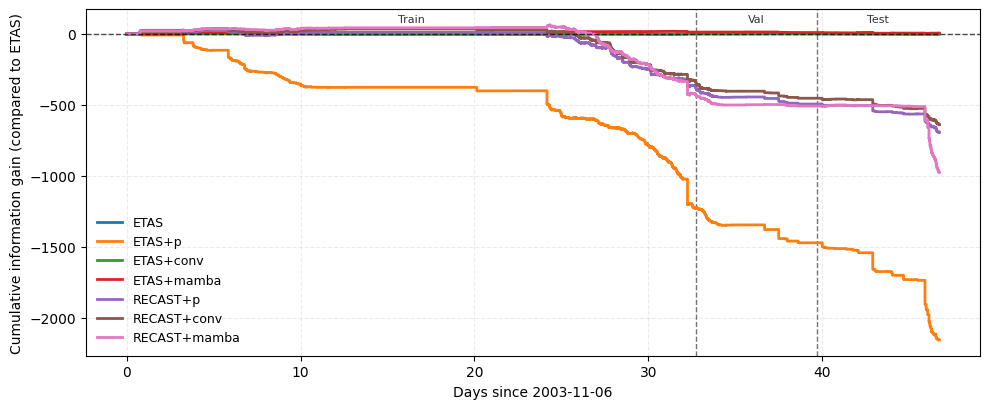

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.2))


def _meta_boundary_days(meta, start_ts, freq, scale, key_t, key_ts):
    if not hasattr(meta, 'get'):
        return None

    value = meta.get(key_t)
    if value is None:
        ts_value = meta.get(key_ts)
        if ts_value is not None and start_ts is not None and freq is not None:
            try:
                value = float((pd.Timestamp(ts_value) - pd.Timestamp(start_ts)) / pd.Timedelta(freq))
            except Exception:
                value = None

    if value is None:
        return None

    try:
        return float(value) * float(scale)
    except Exception:
        return None


def _draw_split_boundaries_paper(ax, x_min, x_max, val_x=None, test_x=None):
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_max <= x_min:
        return

    label_map = {
        'Train': 'Train',
        'Validation': 'Val',
        'Test': 'Test',
    }

    boundaries = []
    if val_x is not None and x_min < val_x < x_max:
        boundaries.append(('Validation', float(val_x)))
    if test_x is not None and x_min < test_x < x_max:
        boundaries.append(('Test', float(test_x)))
    boundaries = sorted(boundaries, key=lambda item: item[1])

    if len(boundaries) == 2:
        val_boundary = boundaries[0][1]
        test_boundary = boundaries[1][1]
        spans = [
            ('Train', x_min, val_boundary),
            ('Validation', val_boundary, test_boundary),
            ('Test', test_boundary, x_max),
        ]
    elif len(boundaries) == 1 and boundaries[0][0] == 'Test':
        test_boundary = boundaries[0][1]
        spans = [
            ('Train', x_min, test_boundary),
            ('Test', test_boundary, x_max),
        ]
    elif len(boundaries) == 1 and boundaries[0][0] == 'Validation':
        val_boundary = boundaries[0][1]
        spans = [
            ('Train', x_min, val_boundary),
            ('Validation', val_boundary, x_max),
        ]
    else:
        spans = []

    for split_name, left, right in spans:
        if right <= left:
            continue
        ax.text(
            0.5 * (left + right),
            0.985,
            label_map.get(split_name, split_name),
            transform=ax.get_xaxis_transform(),
            ha='center',
            va='top',
            fontsize=8,
            color='#333333',
            zorder=3,
        )

    for _, x in boundaries:
        ax.axvline(x, color='black', linestyle='--', linewidth=1.0, alpha=0.55, zorder=2)


x_min = min(float(np.min(res['curve']['time_plot_days'])) for res in model_results)
x_max = max(float(np.max(res['curve']['time_plot_days'])) for res in model_results)
val_boundary_days = _meta_boundary_days(
    catalog_meta,
    start_ts,
    freq,
    TIME_TO_DAYS_SCALE,
    key_t='val_start_t',
    key_ts='val_start_ts',
)
test_boundary_days = _meta_boundary_days(
    catalog_meta,
    start_ts,
    freq,
    TIME_TO_DAYS_SCALE,
    key_t='test_start_t',
    key_ts='test_start_ts',
)

_draw_split_boundaries_paper(ax, x_min, x_max, val_x=val_boundary_days, test_x=test_boundary_days)

for res in model_results:
    t = res['curve']['time_plot_days']
    y = res['curve'][PLOT_CURVE_KEY]
    ax.step(t, y, where='post', linewidth=2.0, label=res['label'])

if PLOT_DELTA_TO_BASELINE:
    ax.axhline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.7)

ax.set_xlabel(TIME_XLABEL)
ax.set_ylabel(PLOT_CURVE_YLABEL)
# ax.set_title(PLOT_TITLE)
ax.grid(alpha=0.25, linestyle='--', linewidth=0.8)
ax.legend(loc='lower left', fontsize=9, frameon=False)
fig.tight_layout()
plt.show()

## 7. Export Artifacts

This cell writes the plot and tabular outputs to disk, including per-time-step curves and a model-level summary CSV for downstream analysis.

In [7]:
import csv

# Export multi-model comparison outputs.
out_dir = PROJECT_ROOT / 'notebooks' / 'outputs'
out_dir.mkdir(parents=True, exist_ok=True)

fig_path = out_dir / f'cum_log_likelihood_compare_{base_args.dataset}_{SPLIT}_{SEQ_INDEX}.pdf'
curve_csv_path = out_dir / f'cum_log_likelihood_compare_{base_args.dataset}_{SPLIT}_{SEQ_INDEX}_curves.csv'
summary_csv_path = out_dir / f'cum_log_likelihood_compare_{base_args.dataset}_{SPLIT}_{SEQ_INDEX}_summary.csv'


def _meta_boundary_days(meta, start_ts, freq, scale, key_t, key_ts):
    if not hasattr(meta, 'get'):
        return None

    value = meta.get(key_t)
    if value is None:
        ts_value = meta.get(key_ts)
        if ts_value is not None and start_ts is not None and freq is not None:
            try:
                value = float((pd.Timestamp(ts_value) - pd.Timestamp(start_ts)) / pd.Timedelta(freq))
            except Exception:
                value = None

    if value is None:
        return None

    try:
        return float(value) * float(scale)
    except Exception:
        return None


def _draw_split_boundaries_paper(ax, x_min, x_max, val_x=None, test_x=None):
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_max <= x_min:
        return

    label_map = {
        'Train': 'Train',
        'Validation': 'Val',
        'Test': 'Test',
    }

    boundaries = []
    if val_x is not None and x_min < val_x < x_max:
        boundaries.append(('Validation', float(val_x)))
    if test_x is not None and x_min < test_x < x_max:
        boundaries.append(('Test', float(test_x)))
    boundaries = sorted(boundaries, key=lambda item: item[1])

    if len(boundaries) == 2:
        val_boundary = boundaries[0][1]
        test_boundary = boundaries[1][1]
        spans = [
            ('Train', x_min, val_boundary),
            ('Validation', val_boundary, test_boundary),
            ('Test', test_boundary, x_max),
        ]
    elif len(boundaries) == 1 and boundaries[0][0] == 'Test':
        test_boundary = boundaries[0][1]
        spans = [
            ('Train', x_min, test_boundary),
            ('Test', test_boundary, x_max),
        ]
    elif len(boundaries) == 1 and boundaries[0][0] == 'Validation':
        val_boundary = boundaries[0][1]
        spans = [
            ('Train', x_min, val_boundary),
            ('Validation', val_boundary, x_max),
        ]
    else:
        spans = []

    for split_name, left, right in spans:
        if right <= left:
            continue
        ax.text(
            0.5 * (left + right),
            0.985,
            label_map.get(split_name, split_name),
            transform=ax.get_xaxis_transform(),
            ha='center',
            va='top',
            fontsize=8,
            color='#333333',
            zorder=3,
        )

    for _, x in boundaries:
        ax.axvline(x, color='black', linestyle='--', linewidth=1.0, alpha=0.55, zorder=2)


val_boundary_days = _meta_boundary_days(
    catalog_meta,
    start_ts,
    freq,
    TIME_TO_DAYS_SCALE,
    key_t='val_start_t',
    key_ts='val_start_ts',
)
test_boundary_days = _meta_boundary_days(
    catalog_meta,
    start_ts,
    freq,
    TIME_TO_DAYS_SCALE,
    key_t='test_start_t',
    key_ts='test_start_ts',
)

# 1) Save comparison plot
fig, ax = plt.subplots(figsize=(10.8, 3))
x_min = min(float(np.min(res['curve']['time_plot_days'])) for res in model_results)
x_max = max(float(np.max(res['curve']['time_plot_days'])) for res in model_results)
_draw_split_boundaries_paper(ax, x_min, x_max, val_x=val_boundary_days, test_x=test_boundary_days)

for res in model_results:
    t_days = res['curve']['time_plot_days']
    y = res['curve'][PLOT_CURVE_KEY]
    ax.step(t_days, y, where='post', linewidth=2.0, label=res['label'])
if PLOT_DELTA_TO_BASELINE:
    ax.axhline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
ax.set_xlabel(TIME_XLABEL, fontsize=11)
ax.set_ylabel(PLOT_CURVE_YLABEL, fontsize=11)
ax.set_title(PLOT_TITLE, fontsize=12)
ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.35)
ax.tick_params(axis='both', labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='lower left', fontsize=9, frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.close(fig)

# 2) Save long-format curve data (includes plotted value and optional delta).
with open(curve_csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'label', 'model_name', 'dataset', 'time_days', 'time_raw',
        'cum_log_likelihood_on_plot', 'cum_nll_on_plot',
        'cum_log_likelihood_delta', 'plot_value', 'plot_key'
    ])
    for res in model_results:
        label = res['label']
        model_name = res['model_name']
        dataset = res['dataset']
        curve = res['curve']

        t_plot_raw = curve['time_plot']
        t_plot_days = curve['time_plot_days']
        ll_on_plot = curve['cum_log_likelihood_on_plot']
        nll_on_plot = curve['cum_nll_on_plot']
        delta_curve = curve.get('cum_log_likelihood_delta', np.full_like(ll_on_plot, np.nan))
        plot_values = curve[PLOT_CURVE_KEY]

        for t_days, t_raw, ll, nll, dlt, p in zip(
            t_plot_days, t_plot_raw, ll_on_plot, nll_on_plot, delta_curve, plot_values
        ):
            writer.writerow([
                label,
                model_name,
                dataset,
                float(t_days),
                float(t_raw),
                float(ll),
                float(nll),
                float(dlt) if np.isfinite(dlt) else '',
                float(p),
                PLOT_CURVE_KEY,
            ])

# 3) Save summary data
with open(summary_csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'label', 'model_name', 'dataset', 'checkpoint_path',
        'num_events_in_nll', 'selected_component', 'final_log_likelihood_selected',
        'computed_selected_nll', 'model_selected_nll',
        'model_time_nll', 'model_total_nll', 'abs_diff',
        'final_delta_vs_baseline'
    ])
    for res in model_results:
        final_delta = (
            float(res['curve']['cum_log_likelihood_delta'][-1])
            if 'cum_log_likelihood_delta' in res['curve']
            else ''
        )
        writer.writerow([
            res['label'],
            res['model_name'],
            res['dataset'],
            res['checkpoint_path'],
            int(res['meta']['num_events_in_nll']),
            NLL_COMPONENT_LABEL,
            float(res['final_log_likelihood_selected']),
            float(res['computed_nll_selected']),
            float(res['nll_ref_selected']),
            float(res['nll_time_ref']),
            float(res['nll_total_ref']),
            float(res['abs_diff']),
            final_delta,
        ])

print(f'Saved comparison plot : {fig_path}')
print(f'Saved curves CSV      : {curve_csv_path}')
print(f'Saved summary CSV     : {summary_csv_path}')

Saved comparison plot : /root/autodl-tmp/em_eqf/notebooks/outputs/cum_log_likelihood_compare_CB_HAB1a_test_0.pdf
Saved curves CSV      : /root/autodl-tmp/em_eqf/notebooks/outputs/cum_log_likelihood_compare_CB_HAB1a_test_0_curves.csv
Saved summary CSV     : /root/autodl-tmp/em_eqf/notebooks/outputs/cum_log_likelihood_compare_CB_HAB1a_test_0_summary.csv
